In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,6)

In [4]:
#Load Dataset
df = pd.read_csv("../data/processed/ecommerce_merged.csv")

In [5]:
df.to_csv("../data/processed/ecommerce_merged.csv", index=False)

In [4]:
df = pd.read_csv("../data/processed/ecommerce_merged.csv")

In [9]:
#Dataset shape
df.shape

(113425, 31)

In [10]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_order_count,total_sales,customer_total_spending,delivery_delay_days,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,2,38.71,82.82,-8.0,On Time / Early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,1,141.46,141.46,-6.0,On Time / Early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,1,179.12,179.12,-18.0,On Time / Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,3.0,450.0,30.0,10.0,20.0,1,72.20,72.20,-13.0,On Time / Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,4.0,250.0,51.0,15.0,15.0,1,28.62,28.62,-10.0,On Time / Early


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   customer_unique_id             113425 non-null  str    
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  str    
 11  customer_state                 113425 non-null  str    
 12  order_item_id                  112650 non

In [12]:
#Missing values analysis
df.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    3229
delivery_delay_days              3229
product_category_name            2378
product_photos_qty               2378
product_description_lenght       2378
product_name_lenght              2378
order_delivered_carrier_date     1968
product_width_cm                  793
product_length_cm                 793
product_weight_g                  793
product_height_cm                 793
seller_id                         775
order_item_id                     775
price                             775
product_id                        775
total_sales                       775
shipping_limit_date               775
freight_value                     775
order_approved_at                 161
customer_state                      0
customer_id                         0
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_cit

In [13]:
#Statistical summary
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_order_count,total_sales,customer_total_spending,delivery_delay_days
count,113425.000000,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000,113425.000000,112650.000000,113425.000000,110196.000000
mean,35102.472965,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546,1.506784,140.644059,192.415782,-12.030201
std,29864.919733,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268,1.335554,190.724394,293.868552,10.160157
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,6.080000,0.000000,-147.000000
25%,11250.000000,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,55.220000,67.430000,-17.000000
50%,24320.000000,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,92.320000,119.250000,-13.000000
75%,59020.000000,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,2.000000,157.937500,208.200000,-7.000000
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,24.000000,6929.310000,13664.080000,188.000000


In [14]:
#Duplicate check
df.duplicated().sum()

np.int64(0)

In [15]:
#Missing value percentage analysis
missing_percentage = (df.isnull().sum()  / len(df)) * 100

missing_percentage.sort_values(ascending=False)

order_delivered_customer_date    2.846815
delivery_delay_days              2.846815
product_category_name            2.096540
product_photos_qty               2.096540
product_description_lenght       2.096540
product_name_lenght              2.096540
order_delivered_carrier_date     1.735067
product_width_cm                 0.699140
product_length_cm                0.699140
product_weight_g                 0.699140
product_height_cm                0.699140
seller_id                        0.683271
order_item_id                    0.683271
price                            0.683271
product_id                       0.683271
total_sales                      0.683271
shipping_limit_date              0.683271
freight_value                    0.683271
order_approved_at                0.141944
customer_state                   0.000000
customer_id                      0.000000
order_id                         0.000000
order_purchase_timestamp         0.000000
order_status                     0

In [16]:
##Business KPI Analysis
#Total Orders

total_orders = df['order_id'].nunique()
total_orders

99441

In [4]:
#Total customers
total_customers = df['customer_unique_id'].unique()
total_customers

<StringArray>
['7c396fd4830fd04220f754e42b4e5bff', 'af07308b275d755c9edb36a90c618231',
 '3a653a41f6f9fc3d2a113cf8398680e8', '7c142cf63193a1473d2e66489a9ae977',
 '72632f0f9dd73dfee390c9b22eb56dd6', '80bb27c7c16e8f973207a5086ab329e2',
 '36edbb3fb164b1f16485364b6fb04c73', '932afa1e708222e5821dac9cd5db4cae',
 '39382392765b6dc74812866ee5ee92a7', '299905e3934e9e181bfb2e164dd4b4f8',
 ...
 '1a3b8f1d0782ebedbcf220a96cbc1655', 'a49e8e11e850592fe685ae3c64b40eca',
 'c716cf2b5b86fb24257cffe9e7969df8', 'e03dbdf5e56c96b106d8115ac336f47f',
 '831ce3f1bacbd424fc4e38fbd4d66d29', '6359f309b166b0196dbf7ad2ac62bb5a',
 'da62f9e57a76d978d02ab5362c509660', '737520a9aad80b3fbbdad19b66b37b30',
 '5097a5312c8b157bb7be58ae360ef43c', '60350aa974b26ff12caad89e55993bd6']
Length: 96096, dtype: str

In [18]:
#Total Revenue
total_revenue = df['total_sales'].sum()
total_revenue

np.float64(15843553.24)

In [19]:
avg_order_value = df['total_sales'].mean()
avg_order_value

np.float64(140.6440589436307)

## Business KPI Analysis

The e-commerce dataset contains 99,441 unique orders from 96,096 unique customers.

The total revenue generated is 15.84 million with an average order value of 140.64 per order.

These KPIs provide a foundation for understanding overall business performance and will be used for further sales and customer behavior analysis.

In [20]:
#Sales Trend Analysis
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

monthly_sales = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
)['total_sales'].sum()

monthly_sales

order_purchase_timestamp
2016-09        354.75
2016-10      56808.84
2016-12         19.62
2017-01     137188.49
2017-02     286280.62
2017-03     432048.59
2017-04     412422.24
2017-05     586190.95
2017-06     502963.04
2017-07     584971.62
2017-08     668204.60
2017-09     720398.91
2017-10     769312.37
2017-11    1179143.77
2017-12     863547.23
2018-01    1107301.89
2018-02     986908.96
2018-03    1155126.82
2018-04    1159698.04
2018-05    1149781.82
2018-06    1022677.11
2018-07    1058728.03
2018-08    1003308.47
2018-09        166.46
2018-10          0.00
Freq: M, Name: total_sales, dtype: float64

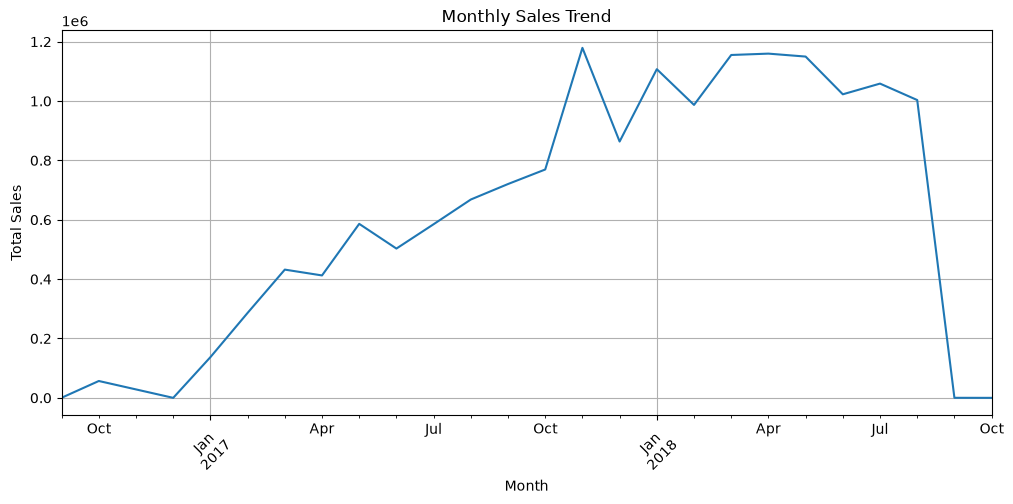

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Monthly Sales Trend Analysis

The monthly sales trend shows the variation in revenue performance over time.

Key observations:
- Sales performance changes across different months.
- Peak sales periods indicate higher customer purchasing activity.
- Lower sales periods can help identify seasonal variations and business opportunities.

This analysis helps understand revenue patterns and supports future sales forecasting.

In [6]:
#Top 10 states by revenue
state_sales = df.groupby('customer_state')['total_sales'].sum().sort_values(ascending=False)

state_sales.head(10)

customer_state
SP    5921678.12
RJ    2129681.98
MG    1856161.49
RS     885826.76
PR     800935.44
BA     611506.67
SC     610213.60
DF     353229.44
GO     347706.93
ES     324801.91
Name: total_sales, dtype: float64

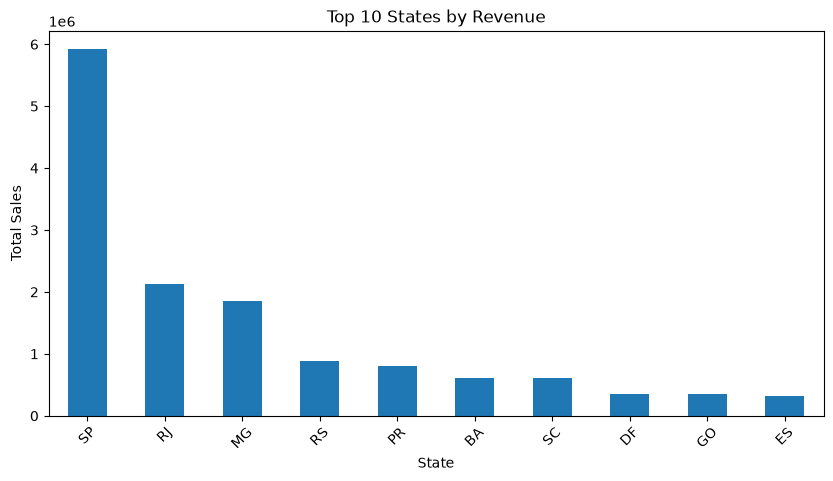

In [7]:
plt.figure(figsize=(10,5))

state_sales.head(10).plot(kind='bar')

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

## Revenue by State Analysis

São Paulo (SP) generated the highest revenue among all states with approximately 5.92 million in sales.

Rio de Janeiro (RJ) and Minas Gerais (MG) are the next highest revenue-generating states.

The analysis shows that sales are concentrated in a few major states, indicating strong customer demand in these regions.

In [8]:
order_status_count = df['order_status'].value_counts()
order_status_count

order_status
delivered      110197
shipped          1186
canceled          706
unavailable       610
invoiced          361
processing        357
created             5
approved            3
Name: count, dtype: int64

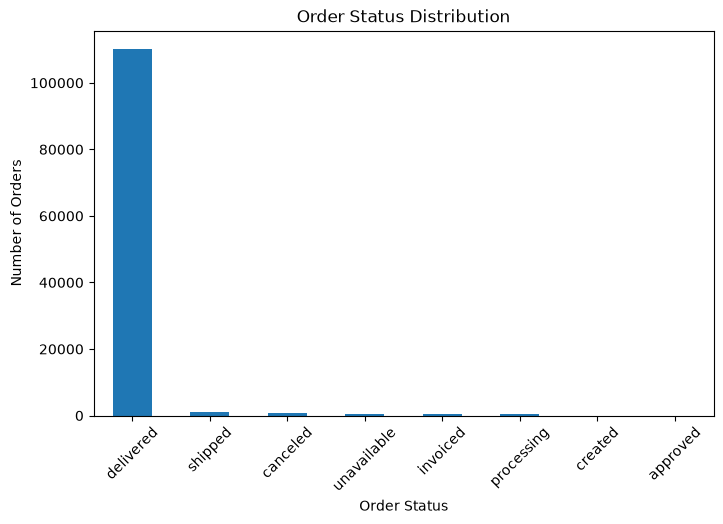

In [9]:
plt.figure(figsize=(8,5))

order_status_count.plot(kind='bar')

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [10]:
category_sales = df.groupby('product_category_name')['total_sales'].sum().sort_values(ascending=False)
category_sales.head(10)

product_category_name
beleza_saude              1441248.07
relogios_presentes        1305541.61
cama_mesa_banho           1241681.72
esporte_lazer             1156656.48
informatica_acessorios    1059272.40
moveis_decoracao           902511.79
utilidades_domesticas      778397.77
cool_stuff                 719329.95
automotivo                 685384.32
ferramentas_jardim         584219.21
Name: total_sales, dtype: float64

## Top Product Categories Analysis

The highest revenue-generating category is beleza_saude, contributing approximately 1.44 million in sales.

Other top-performing categories include relogios_presentes, cama_mesa_banho, esporte_lazer, and informatica_acessorios.

These categories represent the major revenue drivers and can help businesses optimize inventory planning and marketing strategies.

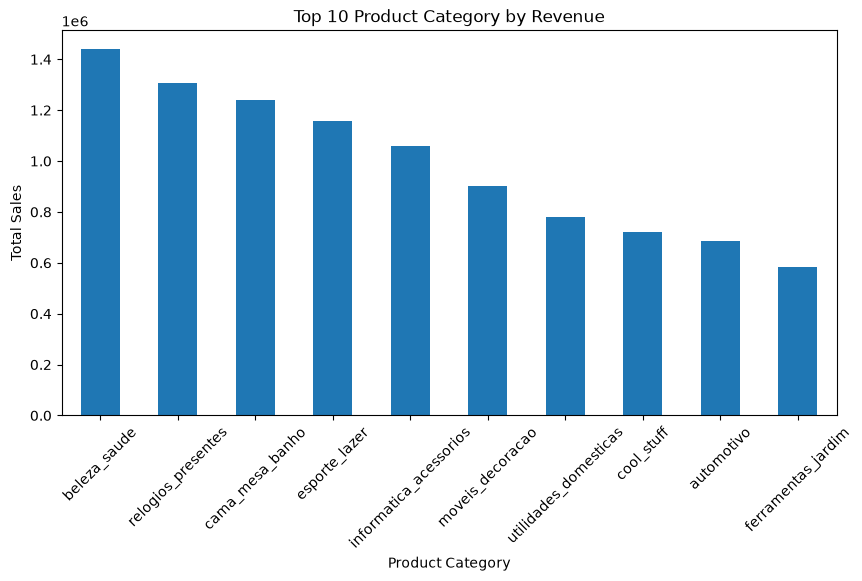

In [11]:
plt.figure(figsize=(10,5))

category_sales.head(10).plot(kind='bar')

plt.title("Top 10 Product Category by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

In [12]:
customer_spending = df.groupby('customer_unique_id')['customer_total_spending'].max().sort_values(ascending=False)
customer_spending.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
48e1ac109decbb87765a3eade6854098     4681.78
Name: customer_total_spending, dtype: float64

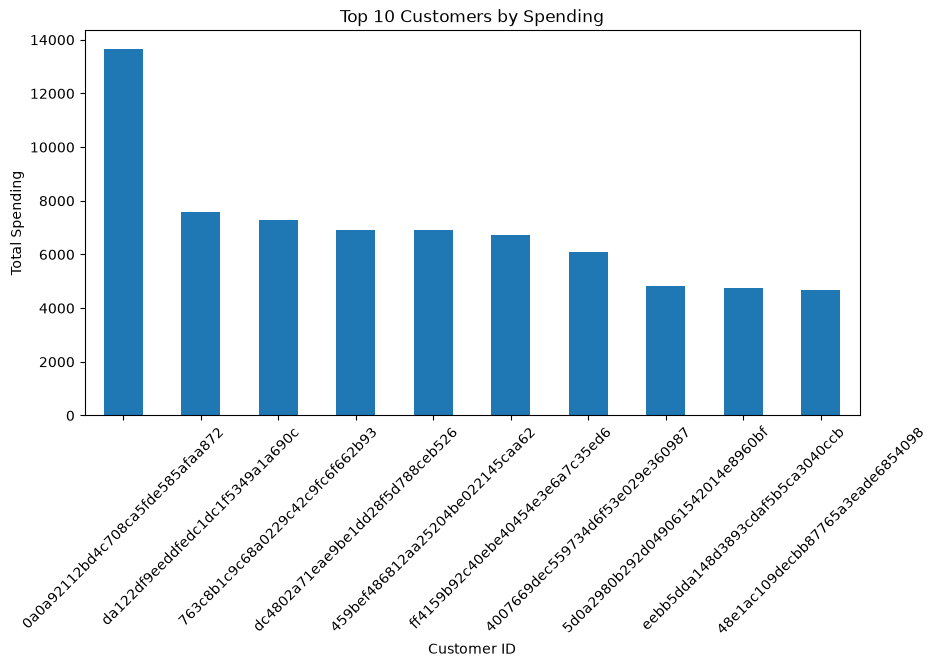

In [13]:
plt.figure(figsize=(10,5))

customer_spending.head(10).plot(kind='bar')

plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")

plt.xticks(rotation=45)
plt.show()

In [14]:
#Customer order Frequency analysis
customer_frequency = df.groupby('customer_unique_id')['order_id'].nunique().sort_values(ascending=False)
customer_frequency.head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
63cfc61cee11cbe306bff5857d00bfe4     6
dc813062e0fc23409cd255f7f53c7074     6
de34b16117594161a6a89c50b289d35a     6
Name: order_id, dtype: int64

In [35]:
#Repeat vs one time customers
repeat_customers = (customer_frequency > 1).sum()
one_time_customers = (customer_frequency == 1).sum()
repeat_customers, one_time_customers

(np.int64(2997), np.int64(93099))

## Customer Order Frequency Analysis

Customer order frequency helps identify customer loyalty and purchasing behavior.

Repeat customers are valuable for business growth because they contribute recurring revenue and can be targeted through retention strategies.

In [36]:
#Revenue Contribution Analysis
customer_revenue = df.groupby('customer_unique_id')['customer_total_spending'].max().sort_values(ascending=False)

customer_revenue.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
48e1ac109decbb87765a3eade6854098     4681.78
Name: customer_total_spending, dtype: float64

## Customer Revenue Contribution Analysis

Customer lifetime spending analysis helps identify high-value customers.

A small group of customers contributes significantly higher revenue, highlighting the importance of customer retention strategies.

Businesses can use this analysis to design loyalty programs and personalized marketing campaigns for valuable customers.

In [37]:
#Repeat Customer Revenue Analysis
repeat_cutometr_ids = customer_frequency[customer_frequency > 1].index

repeat_revenue = df[df['customer_unique_id'].isin(repeat_cutometr_ids)]['total_sales'].sum()

total_revenue = df['total_sales'].sum()

repeat_revenue, total_revenue, (repeat_revenue/total_revenue) * 100

(np.float64(922042.49), np.float64(15843553.24), np.float64(5.819669843202421))

## Repeat Customer Revenue Analysis

Repeat customers contributed approximately 5.82% of total revenue.

Although repeat customers represent a smaller portion of the customer base, they are valuable because they generate recurring revenue.

The analysis suggests an opportunity to improve customer retention through loyalty programs, personalized recommendations, and targeted marketing campaigns.

In [38]:
#Average Orders Per Customer

average_orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique().mean()

average_orders_per_customer

np.float64(1.0348089410589412)

## Average Orders Per Customer Analysis

The average number of orders per customer is approximately 1.03.

This indicates that most customers make a single purchase, highlighting an opportunity to improve customer retention and encourage repeat purchases through loyalty programs, personalized offers, and customer engagement strategies.

In [39]:
#Monthly order volume Trend
monthly_orders = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
)['order_id'].nunique()

monthly_orders

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

## Monthly Order Volume Analysis

The monthly order trend shows strong growth in customer activity from 2017 onwards.

The highest order volume was observed in November 2017 with 7,544 orders, indicating a peak purchasing period.

The increasing order trend highlights business growth and rising customer adoption over time.

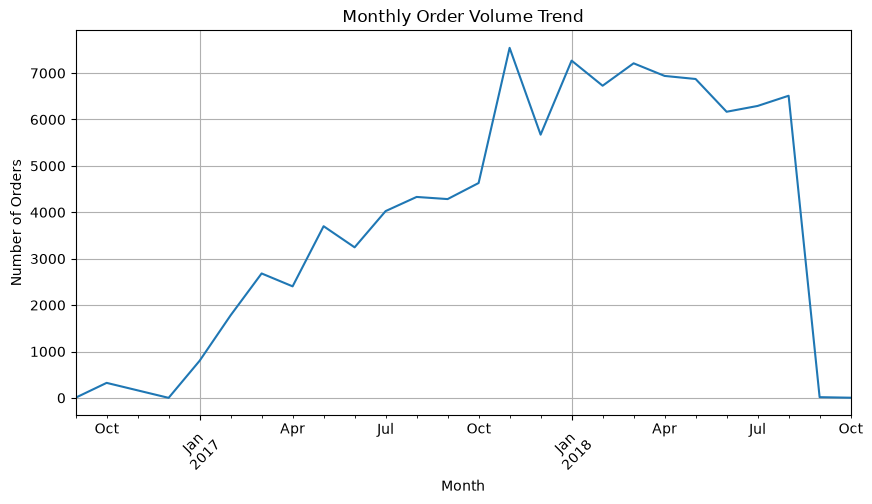

In [40]:
plt.figure(figsize=(10,5))

monthly_orders.plot()

plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [16]:
delivery_status_count = df['delivery_status'].value_counts()
delivery_status_count

delivery_status
On Time / Early    102931
Delayed             10494
Name: count, dtype: int64

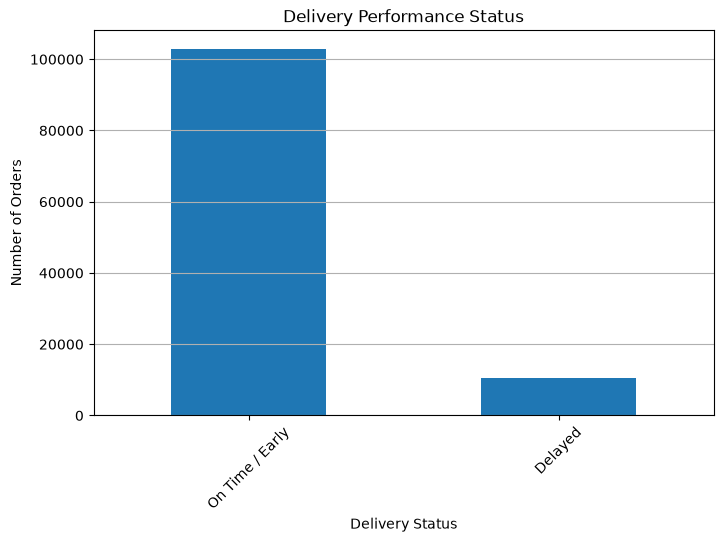

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

delivery_status_count.plot(kind='bar')

plt.title("Delivery Performance Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [18]:
#Average Delivery Delay
df['delivery_delay_days'].describe()

count    110196.000000
mean        -12.030201
std          10.160157
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64

In [19]:
#On-time vs delayed delivery percentage
delivery_percentage = (
    df['delivery_status']
    .value_counts(normalize=True) * 100
).round(2)

delivery_percentage

delivery_status
On Time / Early    90.75
Delayed             9.25
Name: proportion, dtype: float64

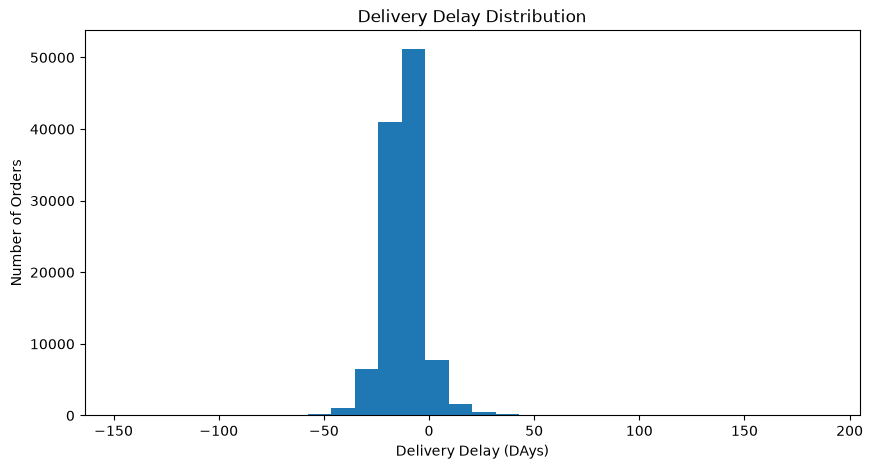

In [20]:
#Delivery Delay Histogram
plt.figure(figsize=(10,5))

df['delivery_delay_days'].dropna().hist(bins=30)

plt.title("Delivery Delay Distribution")
plt.xlabel("Delivery Delay (DAys)")
plt.ylabel("Number of Orders")

plt.grid(False)

plt.show()

In [21]:
#Delivery Performance Analysis
df['delivery_delay_days'].describe()

count    110196.000000
mean        -12.030201
std          10.160157
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64

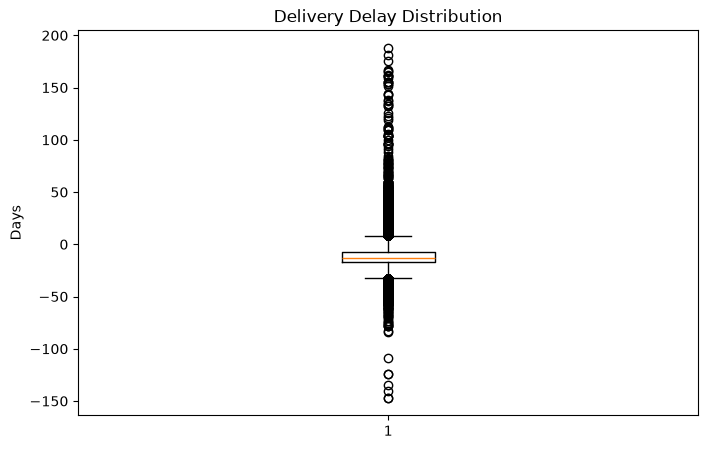

In [22]:
#Delivery Delay Boxplot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df['delivery_delay_days'].dropna())

plt.title("Delivery Delay Distribution")
plt.ylabel("Days")

plt.show()

In [23]:
#AAverage Delivery Delay by state
state_delay = (
    df.groupby('customer_state')['delivery_delay_days']
    .mean()
    .sort_values(ascending=False)
)

state_delay.head(10)

customer_state
AL    -8.735363
MA    -9.906250
SE   -10.002667
ES   -10.646292
BA   -10.982623
CE   -11.103787
SP   -11.207911
MS   -11.229346
PI   -11.527725
SC   -11.572718
Name: delivery_delay_days, dtype: float64

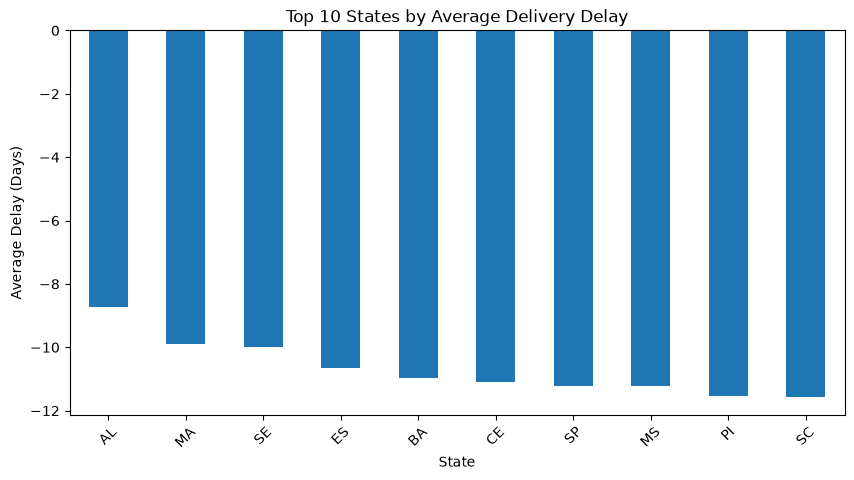

In [25]:
plt.figure(figsize=(10,5))

state_delay.head(10).plot(kind='bar')

plt.title("Top 10 States by Average Delivery Delay")
plt.xlabel("State")
plt.ylabel("Average Delay (Days)")

plt.xticks(rotation=45)
plt.show()

In [6]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'customer_order_count',
 'total_sales',
 'customer_total_spending',
 'delivery_delay_days',
 'delivery_status']

In [8]:
city_sales = (
    df.groupby('customer_city')['total_sales']
    .sum()
    .sort_values(ascending=False)
)

city_sales.head(10)

customer_city
sao paulo         2170227.12
rio de janeiro    1154234.02
belo horizonte     416733.39
brasilia           352305.14
curitiba           244739.87
porto alegre       224064.09
salvador           216772.40
campinas           212541.70
guarulhos          163575.82
niteroi            137919.38
Name: total_sales, dtype: float64

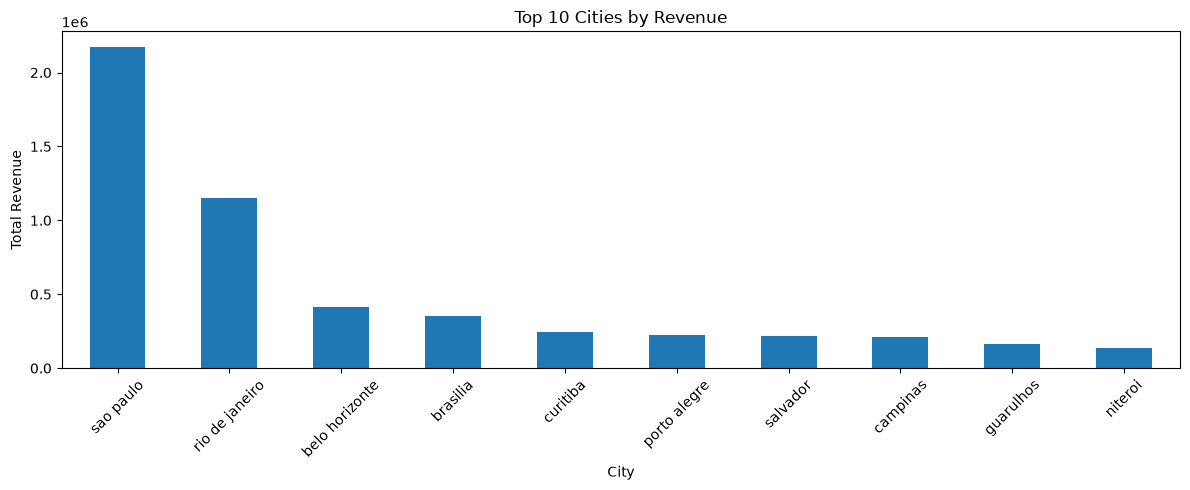

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

city_sales.head(10).plot(kind='bar')

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()